In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Práctica: Análisis y Reducción de Dimensionalidad con LDA

### Descripción:
Vamos a seguir un enfoque similar al de PCA, pero ahora utilizando LDA (Análisis Discriminante Lineal).

### Objetivos:
1. Exploración de los datos: Presentar el dataset y sus características, similar a lo que hicimos con PCA.
2. Aplicación de LDA: Implementar LDA para reducir dimensionalidad y separar las clases.
3. Visualización de la proyección: Visualizar los datos proyectados en las dimensiones de LDA.
4. Entrenamiento de modelos de clasificación sin LDA: Entrenar modelos de clasificación (Regresión Logística, Árbol de Decisión, Random Forest) sin LDA.
5. Entrenamiento de modelos de clasificación con LDA: Usar LDA para reducir las dimensiones y entrenar los modelos de clasificación con las dimensiones reducidas.
6. Comparación de resultados: Comparar el rendimiento de los modelos con y sin LDA.

### Dataset:
El dataset `Wine` contiene 13 características químicas que describen el contenido de varios vinos, y está clasificado en 3 tipos de vinos diferentes. Las características incluyen:
- Alcohol
- Ácido málico
- Cenizas
- Alcalinidad de las cenizas
- Magnesio
- Fenoles totales
- Flavonoides
- Fenoles no flavonoides
- Proantocianinas
- Intensidad de color
- Tono
- OD280/OD315 de vinos diluidos
- Prolina




## Etapa 1: Exploración de los datos

### Objetivo:
Explorar el dataset que vamos a utilizar con LDA. Para mantener consistencia, utilizaremos el mismo dataset de vinos (Wine Dataset).

### Instrucciones:
1. Cargar el conjunto de datos `Wine` disponible en `sklearn`.
2. Mostrar las primeras filas del dataset y las características.
3. Visualizar la distribución de las clases para tener una idea general del problema de clasificación.

### Visualizaciones:
- **Distribución de las clases** en el conjunto de datos.


Aquí cargaremos el dataset de Wine y realizaremos un análisis exploratorio básico.

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

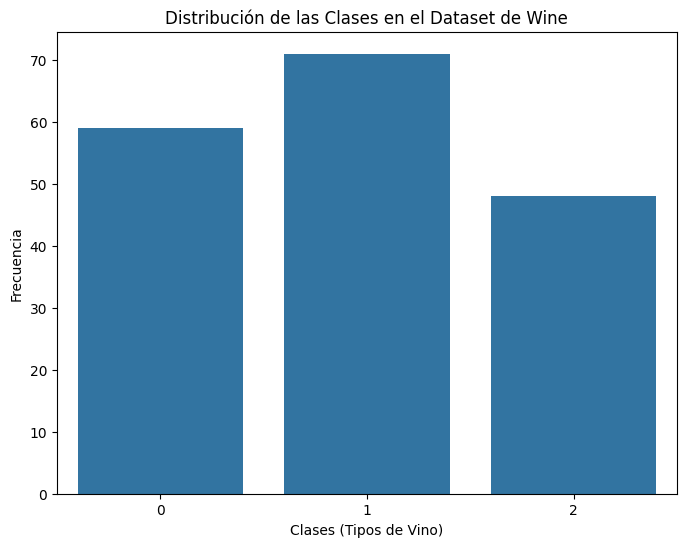

In [2]:
# Importar las bibliotecas necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Cargar el dataset de Wine
wine_data = load_wine()
X_wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y_wine = wine_data.target

# Mostrar las primeras filas del dataset
print(X_wine.head())

# Mostrar la distribución de las clases
plt.figure(figsize=(8, 6))
sns.countplot(x=y_wine)
plt.title("Distribución de las Clases en el Dataset de Wine")
plt.xlabel("Clases (Tipos de Vino)")
plt.ylabel("Frecuencia")
plt.show()


## Etapa 2: Aplicación de LDA

### Objetivo:
En esta etapa, aplicaremos **LDA** al conjunto de datos para reducir las dimensiones y maximizar la separación entre las clases. A diferencia de **PCA**, LDA tiene en cuenta las etiquetas de clase para encontrar las direcciones que mejor separan las clases.

### Instrucciones:
1. Aplicar **LDA** al conjunto de datos para reducirlo a 2 dimensiones, ya que tenemos 3 clases.
2. Visualizar la proyección en el espacio de 2 dimensiones.
3. Comparar la separación de las clases.

### Visualizaciones:
- **Proyección en 2D con LDA**: Un gráfico que muestre las clases proyectadas en las dos primeras componentes lineales discriminantes.


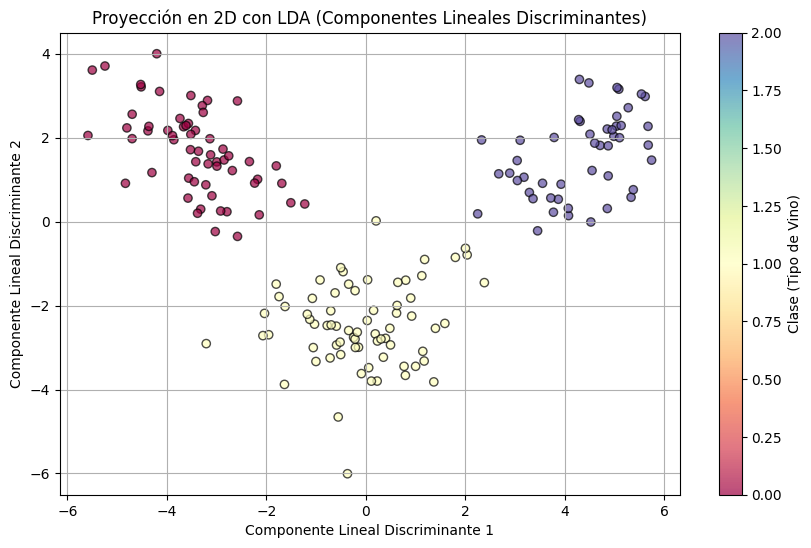

In [8]:
# Importar las librerías necesarias
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Aplicar LDA y reducir a 2 dimensiones
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_wine, y_wine)

# Visualización de la proyección en 2D con LDA
plt.figure(figsize=(10, 6))
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y_wine, cmap='Spectral', edgecolor='k', alpha=0.7)
plt.title('Proyección en 2D con LDA (Componentes Lineales Discriminantes)')
plt.xlabel('Componente Lineal Discriminante 1')
plt.ylabel('Componente Lineal Discriminante 2')
plt.colorbar(label='Clase (Tipo de Vino)')
plt.grid(True)
plt.show()


## Etapa 3: Entrenamiento de Modelos de Clasificación sin LDA

### Objetivo:
Entrenar modelos de clasificación utilizando todas las características originales del conjunto de datos sin aplicar LDA. Estos resultados servirán como referencia para comparar el rendimiento después de aplicar LDA.

### Instrucciones:
1. Entrenar los siguientes modelos de clasificación:
   - **Regresión Logística**
   - **Árbol de Decisión**
   - **Random Forest**
2. Evaluar el rendimiento de cada modelo utilizando:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1-score**
3. Mostrar la **matriz de confusión** y el **reporte de clasificación** para cada modelo.
4. Comparar los resultados obtenidos.

### Visualizaciones:
- **Matriz de Confusión**: Para analizar el rendimiento del modelo en cada clase.
- **Reporte de Clasificación**: Para observar precisión, recall y F1-score por clase.


--- Logistic Regression ---
Accuracy: 0.9815
Precision: 0.9823
Recall: 0.9815
F1 Score: 0.9814


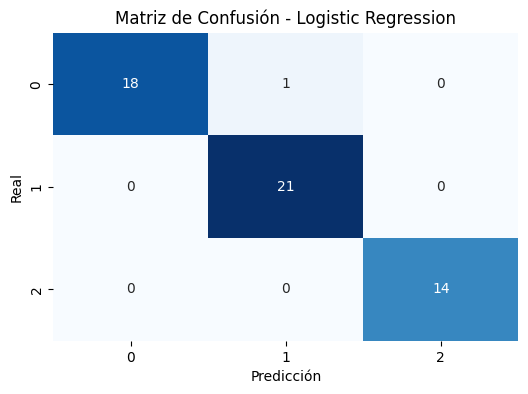

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       1.00      0.95      0.97        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



--- Decision Tree ---
Accuracy: 0.9630
Precision: 0.9638
Recall: 0.9630
F1 Score: 0.9628


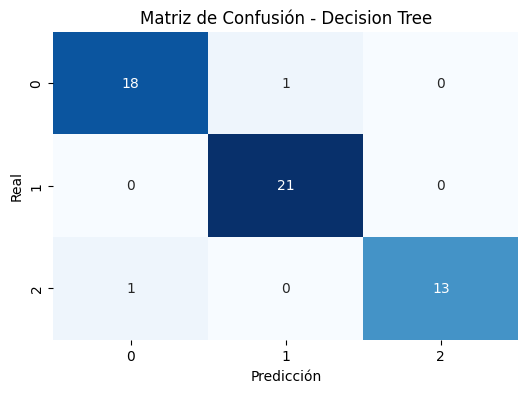

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



--- Random Forest ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


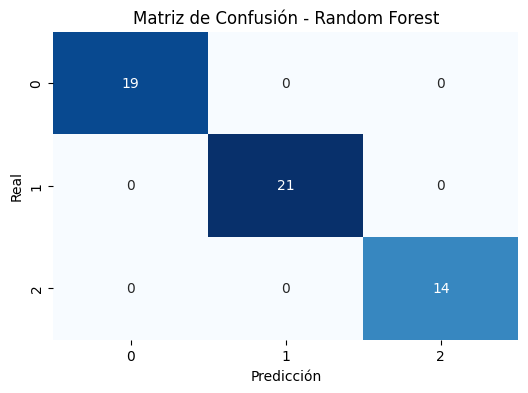

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54





In [9]:
# Importar las bibliotecas necesarias
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
# Dividir los datos en entrenamiento y prueba (para uso posterior)
X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, test_size=0.3, random_state=42)

# Definir los modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Entrenar y evaluar cada modelo
for name, model in models.items():
    print(f"--- {name} ---")

    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Predicción
    y_pred = model.predict(X_test)

    # Mostrar métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Matriz de confusión
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    # Reporte de clasificación
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=wine_data.target_names))
    print("\n")


## Etapa 4: Entrenamiento de Modelos de Clasificación con LDA

### Objetivo:
Entrenar los modelos de clasificación utilizando las componentes discriminantes obtenidas con **LDA**. Compararemos el rendimiento de los modelos después de la reducción de dimensionalidad con los resultados obtenidos en la **Etapa 3**.

### Instrucciones:
1. Aplicar **LDA** para reducir las dimensiones del conjunto de datos.
2. Entrenar los siguientes modelos de clasificación utilizando las componentes discriminantes:
   - **Regresión Logística**
   - **Árbol de Decisión**
   - **Random Forest**
3. Evaluar el rendimiento de cada modelo utilizando:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1-score**
4. Mostrar la **matriz de confusión** y el **reporte de clasificación** para cada modelo.
5. Comparar los resultados con la **Etapa 3**.

### Visualizaciones:
- **Matriz de Confusión**: Para analizar el rendimiento del modelo en cada clase.
- **Reporte de Clasificación**: Para observar precisión, recall y F1-score por clase.


--- Logistic Regression (con LDA) ---
Accuracy: 0.9815
Precision: 0.9824
Recall: 0.9815
F1 Score: 0.9815


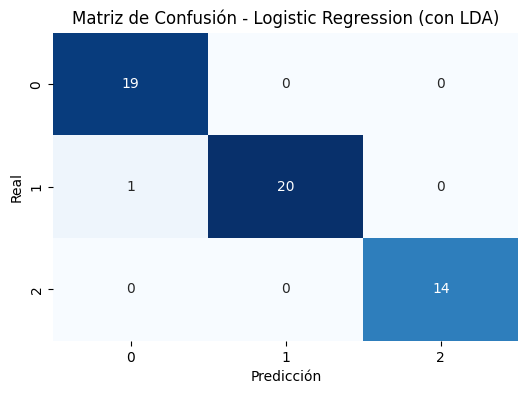

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        19
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



--- Decision Tree (con LDA) ---
Accuracy: 0.9815
Precision: 0.9824
Recall: 0.9815
F1 Score: 0.9815


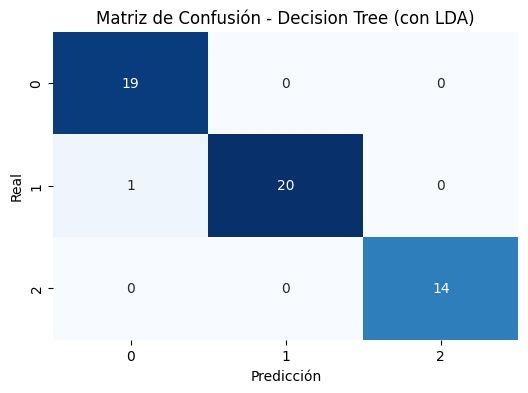

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        19
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



--- Random Forest (con LDA) ---
Accuracy: 0.9815
Precision: 0.9824
Recall: 0.9815
F1 Score: 0.9815


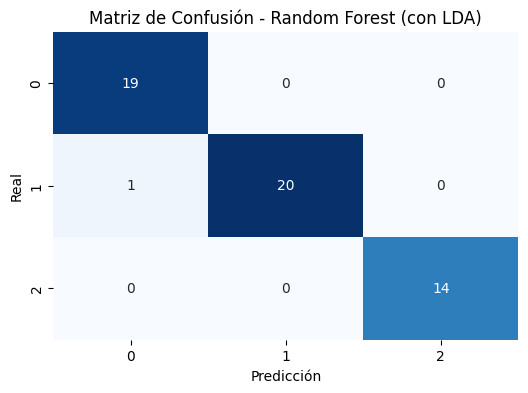

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        19
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54





In [5]:
# Aplicar LDA y reducir a 2 dimensiones
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# Entrenar y evaluar cada modelo usando las componentes obtenidas por LDA
for name, model in models.items():
    print(f"--- {name} (con LDA) ---")

    # Entrenar el modelo
    model.fit(X_train_lda, y_train)

    # Predicción
    y_pred_lda = model.predict(X_test_lda)

    # Mostrar métricas
    accuracy = accuracy_score(y_test, y_pred_lda)
    precision = precision_score(y_test, y_pred_lda, average='weighted')
    recall = recall_score(y_test, y_pred_lda, average='weighted')
    f1 = f1_score(y_test, y_pred_lda, average='weighted')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Matriz de confusión
    conf_matrix_lda = confusion_matrix(y_test, y_pred_lda)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix_lda, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {name} (con LDA)')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    # Reporte de clasificación
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred_lda, target_names=wine_data.target_names))
    print("\n")


## Etapa 5: Comparación de Resultados con y sin LDA

### Objetivo:
Comparar el rendimiento de los modelos de clasificación entrenados sin reducción de dimensionalidad (**Etapa 3**) con los modelos entrenados después de aplicar **LDA** (**Etapa 4**). Evaluaremos si la reducción de dimensionalidad mediante LDA ha mejorado o empeorado el rendimiento de los modelos.

### Instrucciones:
1. Comparar las métricas de rendimiento (**accuracy**, **precision**, **recall**, **F1-score**) para los modelos entrenados con y sin LDA.
2. Visualizar la comparación en gráficos.
3. Analizar si la reducción de dimensionalidad mediante LDA ha mejorado el rendimiento del modelo, y si es así, en qué medida.

### Visualizaciones:
- Gráficos de barras comparativos que muestren las métricas (accuracy, precision, recall, F1-score) para cada modelo con y sin LDA.


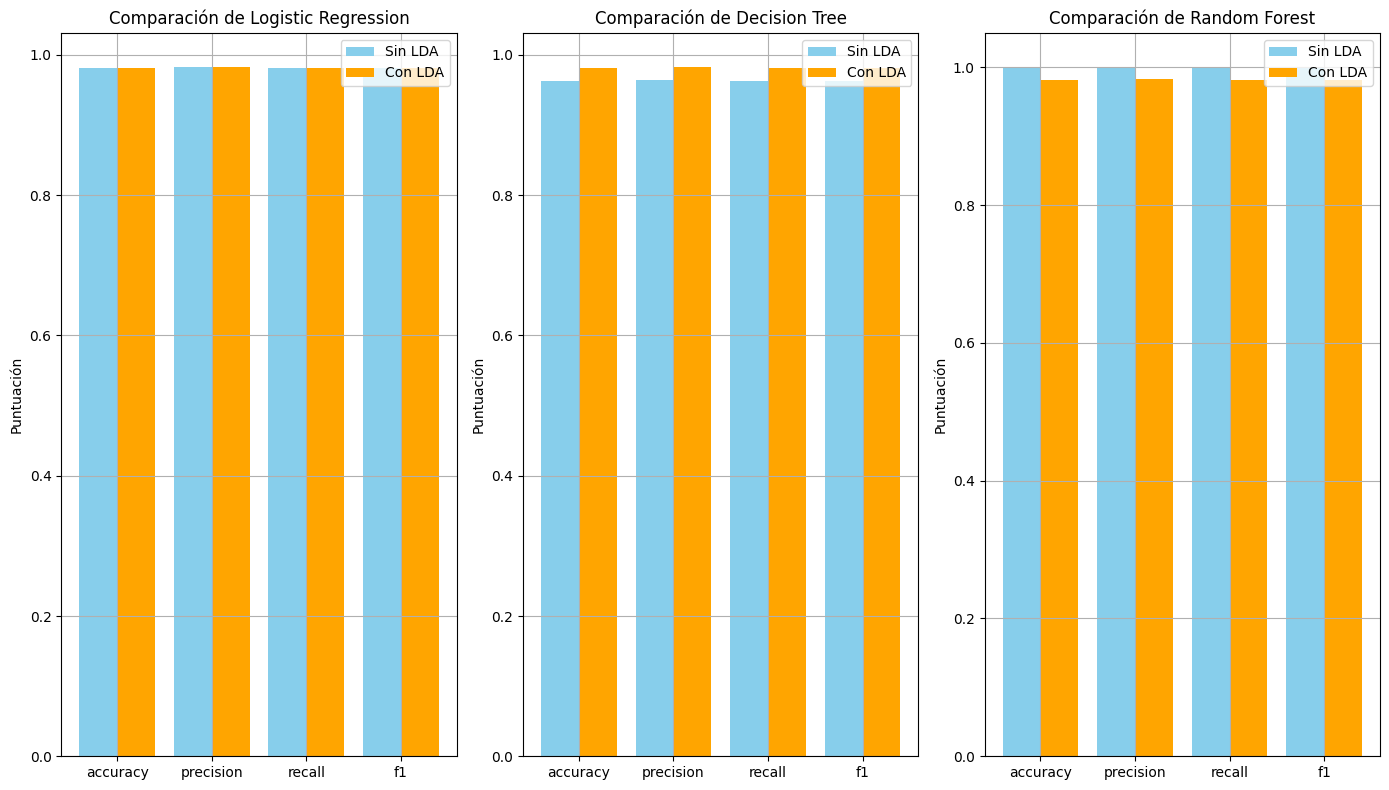

In [6]:
# Definir las métricas obtenidas sin LDA y con LDA
results = {
    'Logistic Regression': {'no_lda': {}, 'lda': {}},
    'Decision Tree': {'no_lda': {}, 'lda': {}},
    'Random Forest': {'no_lda': {}, 'lda': {}}
}

# Entrenar y almacenar los resultados sin LDA (Etapa 3)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name]['no_lda']['accuracy'] = accuracy_score(y_test, y_pred)
    results[name]['no_lda']['precision'] = precision_score(y_test, y_pred, average='weighted')
    results[name]['no_lda']['recall'] = recall_score(y_test, y_pred, average='weighted')
    results[name]['no_lda']['f1'] = f1_score(y_test, y_pred, average='weighted')

# Entrenar y almacenar los resultados con LDA (Etapa 4)
for name, model in models.items():
    model.fit(X_train_lda, y_train)
    y_pred_lda = model.predict(X_test_lda)

    results[name]['lda']['accuracy'] = accuracy_score(y_test, y_pred_lda)
    results[name]['lda']['precision'] = precision_score(y_test, y_pred_lda, average='weighted')
    results[name]['lda']['recall'] = recall_score(y_test, y_pred_lda, average='weighted')
    results[name]['lda']['f1'] = f1_score(y_test, y_pred_lda, average='weighted')

# Visualizar los resultados en gráficos comparativos
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics))

plt.figure(figsize=(14, 8))

for i, model_name in enumerate(models.keys()):
    plt.subplot(1, 3, i+1)
    no_lda_values = [results[model_name]['no_lda'][metric] for metric in metrics]
    lda_values = [results[model_name]['lda'][metric] for metric in metrics]

    plt.bar(x - 0.2, no_lda_values, width=0.4, label='Sin LDA', color='skyblue')
    plt.bar(x + 0.2, lda_values, width=0.4, label='Con LDA', color='orange')

    plt.xticks(x, metrics)
    plt.title(f'Comparación de {model_name}')
    plt.ylabel('Puntuación')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()
